In [32]:
import sympy as sp
import matplotlib.pyplot as plt
import scienceplots


plt.style.use(['science','no-latex'])

In [87]:
t,f=sp.symbols('f t',real=True)
fo=sp.symbols('fo',real=True,positive=True)
a=sp.symbols('a',real=True,positive=True)

In [88]:
y=sp.exp(-sp.Abs(t))

In [89]:
y

exp(-Abs(f))

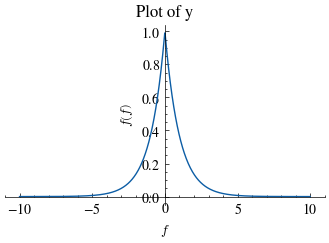

In [90]:
#plot of y 
sp.plot(sp.exp(-t)*sp.Heaviside(t)+sp.exp(t)*sp.Heaviside(-t),title="Plot of y")
plt.show()

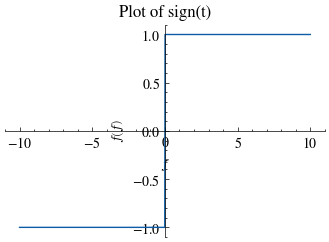

In [91]:
sp.plot(sp.Heaviside(t)-sp.Heaviside(-t),title="Plot of sign(t)")
plt.show()

In [92]:
y=sp.exp(-a*sp.Abs(t))
sp.fourier_transform(y,t,f)

2*a/(a**2 + 4*pi**2*t**2)

In [93]:
g=sp.Heaviside(t)-sp.Heaviside(-t)
F=sp.fourier_transform(g,t,f)
F

-FourierTransform(Heaviside(-f), f, t) + FourierTransform(Heaviside(f), f, t)

In [101]:
H=sp.fourier_transform(sp.Heaviside(t),t,f)
H

FourierTransform(Heaviside(f), f, t)

In [104]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Symbols
t, tau, f = sp.symbols('t tau f', real=True)

# Define two rectangular pulses
x = sp.Piecewise((1, sp.Abs(t) <= 1), (0, True))
h = sp.Piecewise((1, sp.Abs(t) <= 1), (0, True))

# Convolution variable
lam = sp.symbols('lam', real=True)

# Symbolic convolution
conv = sp.integrate(
    x.subs(t, lam) * h.subs(t, t-lam),
    (lam, -sp.oo, sp.oo)
)

conv = sp.simplify(conv)

print("Convolution:")
sp.pprint(conv)

# Fourier Transform
F = sp.fourier_transform(conv, t, f)

print("\nFourier Transform:")
sp.pprint(F)

Convolution:
-Max(-1, t - 1) + Max(-1, t - 1, Min(1, t + 1))

Fourier Transform:
⎧⎛⎛     4⋅ⅈ⋅π⋅f⎞  4⋅ⅈ⋅π⋅f    ⎞  -4⋅ⅈ⋅π⋅f                   
⎪⎝⎝2 - ℯ       ⎠⋅ℯ        - 1⎠⋅ℯ                           
⎪───────────────────────────────────────  for f > 0 ∨ f < 0
⎨                   2  2                                   
⎪                4⋅π ⋅f                                    
⎪                                                          
⎩                   4                         otherwise    


In [105]:
F

Piecewise((((2 - exp(4*I*pi*f))*exp(4*I*pi*f) - 1)*exp(-4*I*pi*f)/(4*pi**2*f**2), (f > 0) | (f < 0)), (4, True))

In [114]:
G=sp.inverse_fourier_transform(F,f,t)
G

InverseFourierTransform(Piecewise((-exp(4*I*pi*f)/(4*pi**2*f**2) + 1/(2*pi**2*f**2) - exp(-4*I*pi*f)/(4*pi**2*f**2), (f > 0) | (f < 0)), (4, True)), f, t)

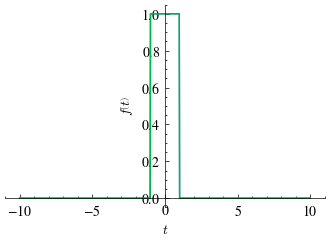

In [109]:
sp.plot(x,h)

In [115]:
g=2*sp.pi*f/((2*sp.pi*4)**2-(2*sp.pi*f)**2)

In [116]:
g

2*pi*f/(-4*pi**2*f**2 + 64*pi**2)

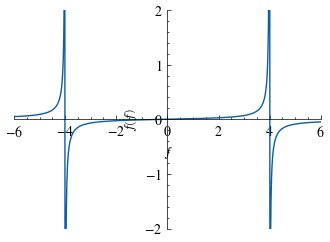

In [125]:
sp.plot(g,xlim=[-6,6],ylim=[-2,2])
plt.show()

Autocorrelation Rxx(tau):
-Max(-1, tau - 1) + Max(-1, tau - 1, Min(1, tau + 1))


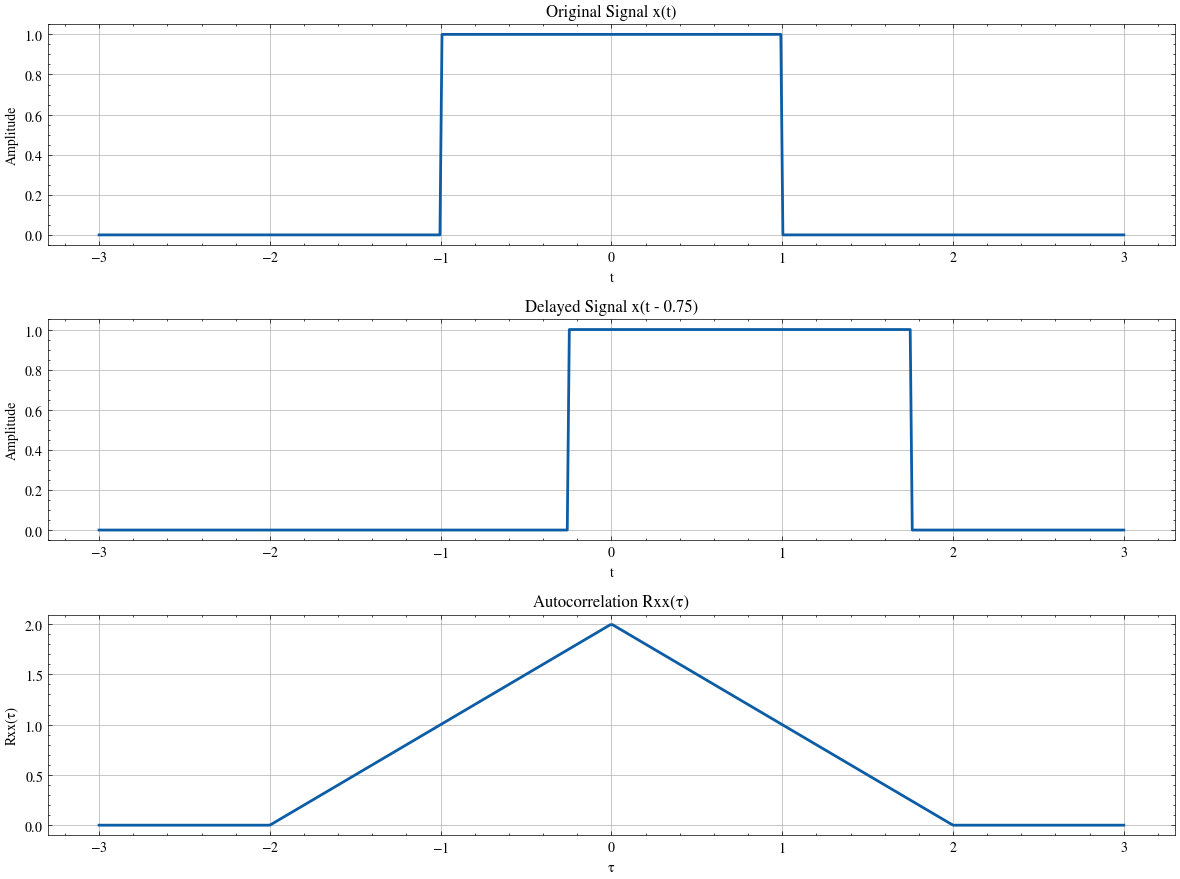

In [130]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------
# Symbolic Variables
# -----------------------------------------------------
t = sp.symbols('t', real=True)
tau = sp.symbols('tau', real=True)

# -----------------------------------------------------
# Original Signal: Rectangular Pulse
# x(t) = 1 for |t| <= 1
# -----------------------------------------------------
x = sp.Piecewise(
    (1, sp.Abs(t) <= 1),
    (0, True)
)

# -----------------------------------------------------
# Delayed Signal
# -----------------------------------------------------
x_delayed = x.subs(t, t - tau)

# -----------------------------------------------------
# Symbolic Autocorrelation
# Rxx(tau) = ∫ x(t)x(t-tau) dt
# -----------------------------------------------------
R = sp.integrate(
    x * x_delayed,
    (t, -sp.oo, sp.oo)
)

R = sp.simplify(R)

print("Autocorrelation Rxx(tau):")
sp.pprint(R)

# -----------------------------------------------------
# Numerical Functions
# -----------------------------------------------------
x_num = sp.lambdify(t, x, "numpy")

# Fixed delay for visualization
tau0 = 0.75
x_delay_num = sp.lambdify(
    t,
    x.subs(t, t - tau0),
    "numpy"
)

R_num = sp.lambdify(tau, R, "numpy")

# -----------------------------------------------------
# Plotting
# -----------------------------------------------------
time = np.linspace(-3, 3, 500)
lags = np.linspace(-3, 3, 500)

plt.figure(figsize=(12, 9))

# Original signal
plt.subplot(3,1,1)
plt.plot(time, x_num(time), linewidth=2)
plt.grid(True)
plt.title("Original Signal x(t)")
plt.xlabel("t")
plt.ylabel("Amplitude")

# Delayed signal
plt.subplot(3,1,2)
plt.plot(time, x_delay_num(time), linewidth=2)
plt.grid(True)
plt.title(f"Delayed Signal x(t - {tau0})")
plt.xlabel("t")
plt.ylabel("Amplitude")

# Autocorrelation
plt.subplot(3,1,3)
plt.plot(lags, R_num(lags), linewidth=2)
plt.grid(True)
plt.title("Autocorrelation Rxx(τ)")
plt.xlabel("τ")
plt.ylabel("Rxx(τ)")

plt.tight_layout()
plt.show()

In [131]:
R = sp.integrate(
    x * x_delayed,
    (t, -sp.oo, sp.oo)
)

In [132]:
R

-Max(-1, tau - 1) + Max(-1, tau - 1, Min(1, tau + 1))